# Fig: Infotaxis vs MAP comparison: pmax_th=0.95

Reference: 
- `20251027_infotaxis_vs_MP_cmp_random_target_across_pm_hist_2conditions_1e-5.ipynb`
- `20251214_fig_infotaxis_MAP_cmp.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from data_prep_plot.plot_utils import bar_violinplot_success
from data_prep_plot.simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  514
Mean:    left: 10.498  right: 13.940
Median:  left: 10.000  right: 13.500

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  991    right:  545
Mean:    left: 12.764  right: 18.804
Median:  left: 12.000  right: 18.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  971    right:  534
Mean:    left: 14.769  right: 22.596
Median:  left: 14.000  right: 22.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  976    right:  501
Mean:    left: 21.679  right: 34.383
Median:  left: 20.000  right: 32.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


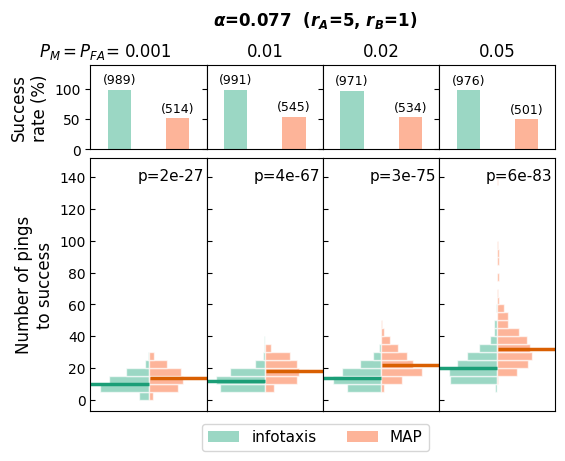

Samples: left:  977    right:  339
Mean:    left: 7.558  right: 10.882
Median:  left: 7.000  right: 11.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  974    right:  303
Mean:    left: 11.134  right: 17.482
Median:  left: 10.000  right: 17.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  969    right:  300
Mean:    left: 14.923  right: 23.050
Median:  left: 14.000  right: 22.500

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  959    right:  298
Mean:    left: 32.337  right: 43.872
Median:  left: 29.000  right: 42.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


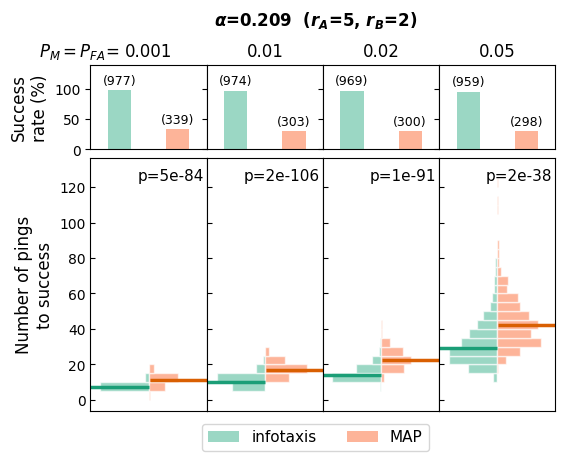

Samples: left:  986    right:  524
Mean:    left: 29.492  right: 36.704
Median:  left: 28.000  right: 33.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  985    right:  535
Mean:    left: 33.924  right: 44.779
Median:  left: 33.000  right: 42.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  968    right:  520
Mean:    left: 38.241  right: 55.029
Median:  left: 35.500  right: 52.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  967    right:  510
Mean:    left: 58.238  right: 80.696
Median:  left: 50.000  right: 72.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


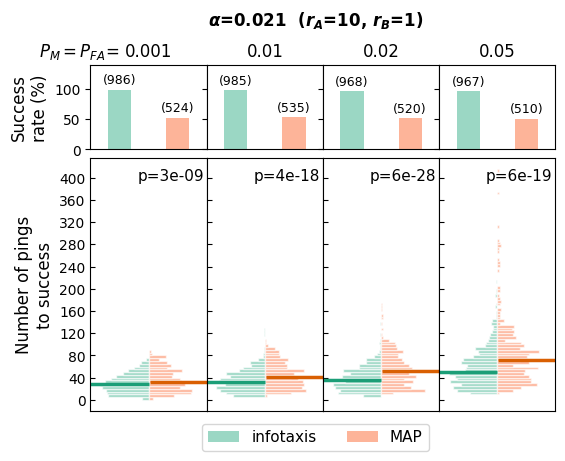

Samples: left:  980    right:  313
Mean:    left: 15.112  right: 20.220
Median:  left: 14.000  right: 19.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  966    right:  332
Mean:    left: 21.005  right: 30.545
Median:  left: 20.000  right: 29.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  968    right:  306
Mean:    left: 28.171  right: 40.856
Median:  left: 26.000  right: 39.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  961    right:  244
Mean:    left: 61.033  right: 82.734
Median:  left: 59.000  right: 76.500

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


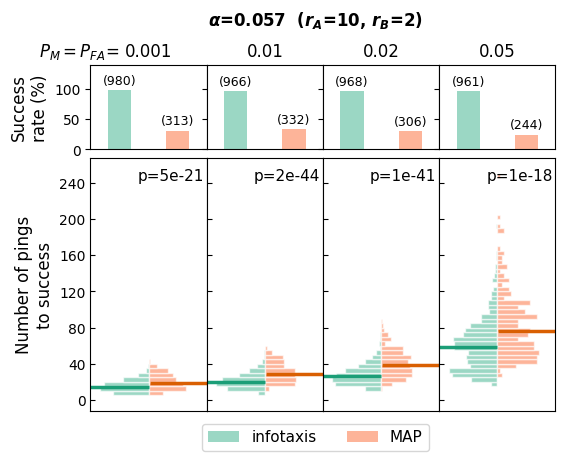

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_all = [0.001, 0.01, 0.02, 0.05]

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_MAP_match_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th=1e-5

        df_x_all = []
        df_y_all = []
        for pm in pm_all:
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="MAP", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)


        fig = bar_violinplot_success(
            cr=cr, br=br, pm_all=pm_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="infotaxis", y_str="MAP",
            color_idx_left=0, color_idx_right=1,
            comparison_type="simple",
            stats_type="less",
            colors = sns.color_palette("Set2"),
            colors_dark = sns.color_palette("Dark2"),
            print_stats=True,
        )

        fig.savefig(
            path_fig / f"fig_infotaxis_MAP_cmp_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )